### 04-01 Evaluation metrics for binary classification

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [62]:
df = pd.read_csv('data-week-3.csv')
df.columns =df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors="coerce")
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == "yes").astype(int)

In [63]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [64]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [65]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']


In [66]:
df_full_train = df_full_train.reset_index(drop=True)

numerical = ["tenure", "monthlycharges", "totalcharges"]
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod',]

In [67]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

In [75]:
model = LogisticRegression()
model.fit(X_train, y_train)


val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(churn_decision == y_val).mean()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8034066713981547

### 04-02 Accuracy

Accuracy tells us the fraction of correct predictions

In [76]:
len(y_val)

1409

In [77]:
(y_val == churn_decision).sum()

1132

In [78]:
1132/1409

0.8034066713981547

In [79]:
thresholds = np.linspace(0, 1, 21)

thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [80]:
scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    print(f"{t:.2f} {score:.3f}")
    scores.append(score)


0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.666
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.734
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


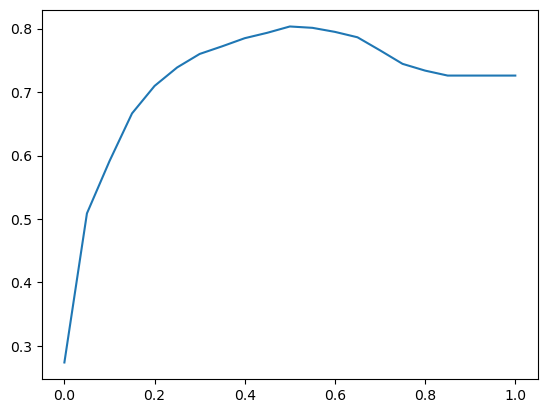

In [81]:
plt.plot(thresholds, scores)

In [82]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, churn_decision)

0.7260468417317246

Dummy model

In [83]:
from collections import Counter

Counter(y_pred >= 1.0)

Counter({False: 1409})

The issue with accuracy is that it does not tell us how good the model is for this particular case, because if we look at the distribution of y, there is a lot more non-churning than churning.

In [85]:
y_val.mean()

0.2739531582682754

In [86]:
1 - y_val.mean()

0.7260468417317246

=> Class imbalance (3:1)

Note that if we build a dummy model in which the decision cutoff is 1, so the algorithm predicts that no clients will churn, the accuracy would be 73%.

### 04-03 Confusion table

Churn - Positive class => Customer churned (TP), Customer did not churn (FP)
<br>No churn - Negative class => Customer did not churn (TN), Customer churned (FN)

In [87]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [88]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [91]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

In [92]:
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [94]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[922, 101],
       [176, 210]])

In [98]:
# Normalise

(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

Accuracy = 65% + 15% = 80%

### 03-04 Precision and Recall

Accuracy = (tp + tn) / (tp + tn + fp + fn)
<br>
Precision (out of positive predictions) = tp / (tp + fp)
<br>
Recall (out of actual positive) = tp / (tp + fn)

In [99]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

accuracy

0.8034066713981547

In [100]:
precision = tp / (tp + fp)
precision

0.6752411575562701

In [101]:
recall = tp / (tp + fn)
recall

0.5440414507772021

80% accuracy seemed good, but precision and recall tell another story. Sending discount mail to 33% of customers who do not need it, and failing to identify 46% of customers who churn.

### 04-05 ROC (Receiver Operating Characteristic)

False positive rate, fpr = fp / (tn + fp) [Aim is to decrease it]
<br>
True positive rate, tpr = tp / (fn + tp) [Aim is to increase it]

In [103]:
tpr = tp / (tp + fn)
tpr

0.5440414507772021

In [104]:
fpr = fp / (fp + tn)
fpr

0.09872922776148582

In [107]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, tn, fn))

In [108]:
scores

[(0.0, 386, 1023, 0, 0),
 (0.01, 385, 913, 110, 1),
 (0.02, 384, 830, 193, 2),
 (0.03, 383, 766, 257, 3),
 (0.04, 381, 715, 308, 5),
 (0.05, 379, 685, 338, 7),
 (0.06, 377, 661, 362, 9),
 (0.07, 372, 641, 382, 14),
 (0.08, 371, 613, 410, 15),
 (0.09, 369, 580, 443, 17),
 (0.1, 366, 556, 467, 20),
 (0.11, 365, 528, 495, 21),
 (0.12, 365, 509, 514, 21),
 (0.13, 360, 477, 546, 26),
 (0.14, 354, 453, 570, 32),
 (0.15, 351, 435, 588, 35),
 (0.16, 347, 419, 604, 39),
 (0.17, 346, 401, 622, 40),
 (0.18, 344, 384, 639, 42),
 (0.19, 338, 369, 654, 48),
 (0.2, 333, 356, 667, 53),
 (0.21, 330, 341, 682, 56),
 (0.22, 323, 322, 701, 63),
 (0.23, 320, 313, 710, 66),
 (0.24, 316, 303, 720, 70),
 (0.25, 309, 291, 732, 77),
 (0.26, 304, 281, 742, 82),
 (0.27, 303, 270, 753, 83),
 (0.28, 295, 256, 767, 91),
 (0.29, 291, 244, 779, 95),
 (0.3, 284, 236, 787, 102),
 (0.31, 280, 230, 793, 106),
 (0.32, 278, 226, 797, 108),
 (0.33, 276, 221, 802, 110),
 (0.34, 274, 212, 811, 112),
 (0.35000000000000003, 272,

In [109]:
pd.DataFrame(scores)

,0,1,2,3,4
0,0.00,386,1023,0,0
1,0.01,385,913,110,1
2,0.02,384,830,193,2
3,0.03,383,766,257,3
4,0.04,381,715,308,5
...,...,...,...,...,...
96,0.96,0,0,1023,386
97,0.97,0,0,1023,386
98,0.98,0,0,1023,386
99,0.99,0,0,1023,386


In [121]:
columns = ['threshold', 'tp', 'fp', 'tn', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores

,threshold,tp,fp,tn,fn
0,0.00,386,1023,0,0
1,0.01,385,913,110,1
2,0.02,384,830,193,2
3,0.03,383,766,257,3
4,0.04,381,715,308,5
...,...,...,...,...,...
96,0.96,0,0,1023,386
97,0.97,0,0,1023,386
98,0.98,0,0,1023,386
99,0.99,0,0,1023,386


In [122]:
df_scores[::10]

,threshold,tp,fp,tn,fn
0,0.0,386,1023,0,0
10,0.1,366,556,467,20
20,0.2,333,356,667,53
30,0.3,284,236,787,102
40,0.4,249,166,857,137
50,0.5,210,101,922,176
60,0.6,150,53,970,236
70,0.7,76,20,1003,310
80,0.8,13,2,1021,373
90,0.9,0,0,1023,386


In [123]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [124]:
df_scores[::10]

,threshold,tp,fp,tn,fn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,556,467,20,0.948187,0.543500
20,0.2,333,356,667,53,0.862694,0.347996
30,0.3,284,236,787,102,0.735751,0.230694
40,0.4,249,166,857,137,0.645078,0.162268
50,0.5,210,101,922,176,0.544041,0.098729
60,0.6,150,53,970,236,0.388601,0.051808
70,0.7,76,20,1003,310,0.196891,0.019550
80,0.8,13,2,1021,373,0.033679,0.001955
90,0.9,0,0,1023,386,0.000000,0.000000


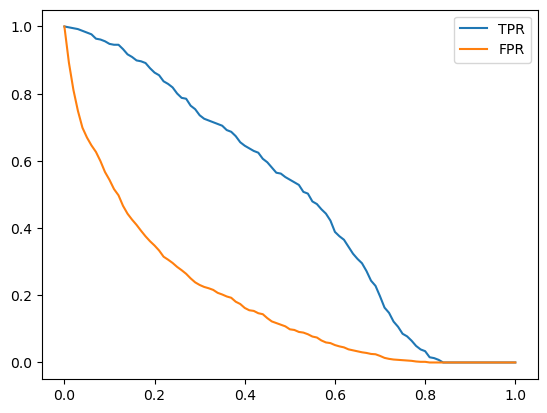

In [125]:
plt.plot(df_scores.threshold, df_scores['tpr'], label="TPR")
plt.plot(df_scores.threshold, df_scores['fpr'], label="FPR")
plt.legend()

#### Random model

In [126]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

y_rand

array([4.17022005e-01, 7.20324493e-01, 1.14374817e-04, ...,
       7.73916250e-01, 3.34276405e-01, 8.89982208e-02])

In [127]:
((y_rand >= 0.5) == y_val).mean()

0.5017743080198722

In [160]:
def tpr_fpr_dataframe( y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:

        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, tn, fn))
    
    columns = ['threshold', 'tp', 'fp', 'tn', 'fn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [161]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [162]:
df_rand[::10]

,threshold,tp,fp,tn,fn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,347,923,100,39,0.898964,0.902248
20,0.2,307,822,201,79,0.795337,0.803519
30,0.3,276,724,299,110,0.715026,0.707722
40,0.4,237,624,399,149,0.613990,0.609971
50,0.5,202,518,505,184,0.523316,0.506354
60,0.6,161,409,614,225,0.417098,0.399804
70,0.7,121,302,721,265,0.313472,0.295210
80,0.8,78,206,817,308,0.202073,0.201369
90,0.9,40,101,922,346,0.103627,0.098729


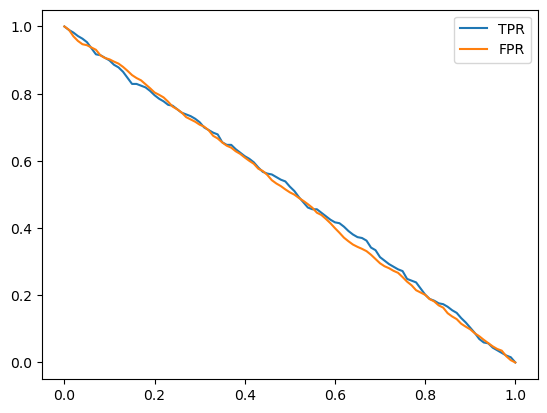

In [163]:
plt.plot(df_rand.threshold, df_rand['tpr'], label="TPR")
plt.plot(df_rand.threshold, df_rand['fpr'], label="FPR")
plt.legend()

#### Ideal model

In [164]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

num_neg, num_pos

(1023, 386)

In [165]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1])

In [166]:
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [167]:
1 - y_val.mean()

0.7260468417317246

In [168]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

1.0

In [169]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)

In [170]:
df_ideal[::10]

,threshold,tp,fp,tn,fn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,141,0,1.000000,0.862170
20,0.2,386,741,282,0,1.000000,0.724340
30,0.3,386,600,423,0,1.000000,0.586510
40,0.4,386,459,564,0,1.000000,0.448680
50,0.5,386,319,704,0,1.000000,0.311828
60,0.6,386,178,845,0,1.000000,0.173998
70,0.7,386,37,986,0,1.000000,0.036168
80,0.8,282,0,1023,104,0.730570,0.000000
90,0.9,141,0,1023,245,0.365285,0.000000


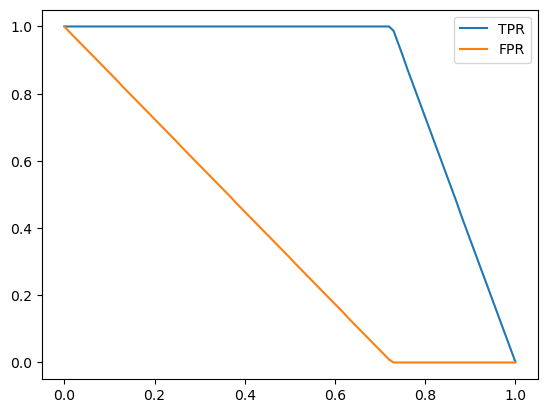

In [171]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label="TPR")
plt.plot(df_ideal.threshold, df_ideal['fpr'], label="FPR")
plt.legend()

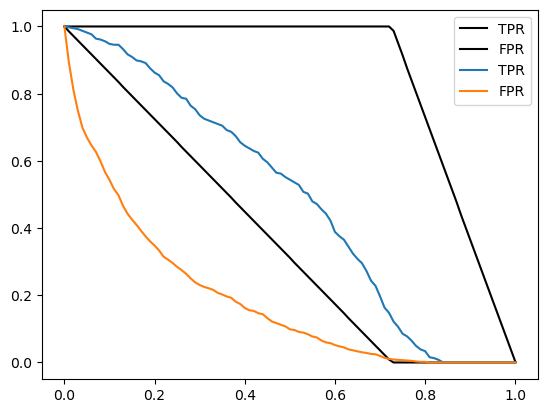

In [172]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label="TPR", color="black")
plt.plot(df_ideal.threshold, df_ideal['fpr'], label="FPR", color="black")

plt.plot(df_scores.threshold, df_scores['tpr'], label="TPR")
plt.plot(df_scores.threshold, df_scores['fpr'], label="FPR")
plt.legend()

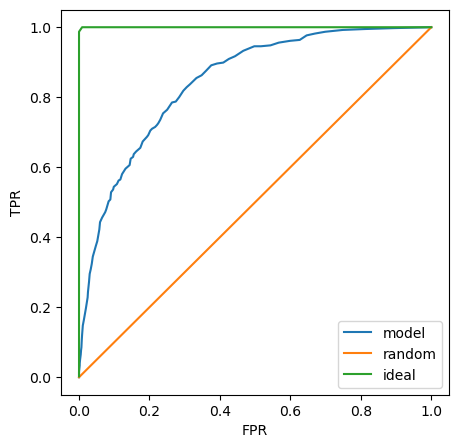

In [177]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='model')
#plt.plot(df_rand.fpr, df_rand.tpr, label='random')
plt.plot([0, 1], [0, 1], label='random')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


In [178]:
from sklearn.metrics import roc_curve

In [179]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

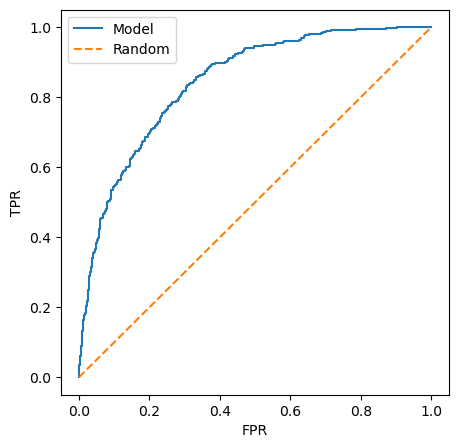

In [181]:
plt.figure(figsize=(5,5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

### 04-06 AUC

In [182]:
from sklearn.metrics import auc

# Not necessarily for ROC, but for any curve

In [183]:
auc(fpr, tpr)

0.8438606354367677

In [184]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

0.8438606354367677

AUC is the probability that a randomly selected churn individual has a higher score than a randomly selected non-churn individual and show how well the model can separate one class from another.

In [ ]:
neg = y_pred[y_val == 0] # Scores for negative examples
pos = y_pred[y_val == 1] # Scores for positive examples

In [187]:
import random

In [ ]:
n = 1000000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos) - 1) # Upper bound is inclusive
    neg_ind = random.randint(0, len(neg) - 1)

    if pos[pos_ind] > neg[neg_ind]:
        success = success + 1

success / n

0.843698

In [ ]:
n = 1000000
pos_ind = np.random.randint(0, len(pos), size=n) # Upper bound is exclusive
neg_ind = np.random.randint(0, len(neg), size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

0.843933

### 04-07 Cross-Validation

In [224]:
def train(df, y_train, C=1.0):
    dicts = df[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=10000) # Smalller C imply stronger regularisation
    model.fit(X_train, y_train)

    return dv, model

In [225]:
dv, model = train(df_train, y_train, C=10)

In [202]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [203]:
y_pred = predict(df_val, dv, model)

In [204]:
from sklearn.model_selection import KFold

In [205]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [206]:
kfold.split(df_full_train)

<generator object _BaseKFold.split at 0x122a2a020>

In [207]:
next(kfold.split(df_full_train))

(array([   0,    1,    2, ..., 5631, 5632, 5633]),
 array([   4,   21,   28,   33,   44,   58,   67,   72,   79,   81,   82,
          98,  101,  116,  119,  125,  126,  136,  141,  147,  161,  169,
         179,  192,  196,  200,  206,  214,  222,  231,  250,  255,  259,
         276,  280,  285,  301,  308,  313,  314,  325,  343,  354,  359,
         383,  386,  407,  420,  428,  433,  440,  447,  457,  473,  486,
         496,  501,  503,  507,  545,  554,  557,  566,  574,  580,  582,
         592,  605,  608,  623,  634,  636,  645,  662,  667,  684,  687,
         689,  729,  745,  758,  763,  778,  783,  792,  795,  808,  839,
         840,  847,  850,  858,  867,  870,  871,  881,  899,  906,  927,
         929,  931,  940,  943,  976,  984,  987,  988, 1005, 1016, 1028,
        1034, 1038, 1050, 1056, 1074, 1079, 1117, 1122, 1123, 1131, 1134,
        1139, 1144, 1155, 1159, 1163, 1169, 1179, 1198, 1206, 1216, 1238,
        1247, 1256, 1272, 1297, 1298, 1310, 1344, 1356, 1370,

In [209]:
# To see progress

from tqdm.auto import tqdm

In [232]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)

        scores.append(auc)
        
    print(f"C={C} {np.mean(scores):.3f} +- {np.std(scores):.3f}")


  0%|          | 0/7 [00:00<?, ?it/s]

C=0.001 0.825 +- 0.009
C=0.01 0.840 +- 0.008
C=0.1 0.842 +- 0.007
C=0.5 0.842 +- 0.007
C=1 0.842 +- 0.007
C=5 0.842 +- 0.007
C=10 0.842 +- 0.007


In [233]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8584005005037537

In [234]:
scores

[0.843937169815764,
 0.8447660078135347,
 0.8336383704595625,
 0.8348728176760248,
 0.8520402560321295]

In [212]:
np.mean(scores), np.std(scores)

(0.8409674927183328, 0.012139907617797093)

In [214]:
f"{np.mean(scores):.3f} +- {np.std(scores):.3f}"

'0.841 +- 0.012'

In [200]:
len(train_idx), len(val_idx)

(5070, 564)

In [201]:
len(df_full_train)

5634

Hold-out validation as in previous weeks when dataset is large
<br>
Cross-validation if dataset is smaller or to show how stable the model is with std deviation
<br>
Bigger datasets - Splits could be 2 or 3
<br>
Smaller datasets - More splits like 10

### 04-08 Summary

### 04-09 Explore more